# US Rates & Inflation Dashboard

Tracks the Fed funds effective rate, the US Treasury curve, and CPI inflation against the Fed's 2% target. All figures are pulled from FRED and the US Treasury's own public feed — no API key required.

**Last data pull:** 14 September 2026


In [1]:
import pandas as pd

ff = pd.read_csv('data_us_fedfunds_monthly.csv', parse_dates=['date'])
cpi = pd.read_csv('data_us_cpi_monthly.csv', parse_dates=['date'])
cpi['yoy'] = cpi['cpi_index'].pct_change(12) * 100
ust = pd.read_csv('data_us_treasury_yields_daily.csv', parse_dates=['date'])
ff.tail(3)

      date  fed_funds_rate
2026-06-01            3.63
2026-07-01            3.63
2026-08-01            3.63


## 1. Policy rate vs. 10Y Treasury yield

The Fed funds series has a full 24-month history; the Treasury daily-yield feed used for this build only returned data back to 2 Jan 2026 (see *Limitations*), so the 10Y print is shown as a labelled snapshot rather than a full second line — that snapshot point is genuine, current data, just not a full time series.

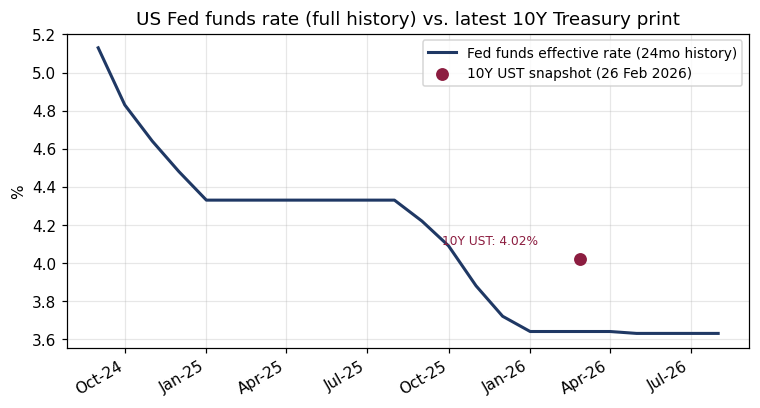

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(ff['date'], ff['fed_funds_rate'], label='Fed funds effective rate (24mo history)')
latest = ust.iloc[-1]
ax.scatter([latest['date']], [latest['y10']], color='firebrick', zorder=5,
           label=f"10Y UST snapshot ({latest['date'].date()})")
ax.set_title('US Fed funds rate vs. latest 10Y Treasury print'); ax.legend(); plt.show()

## 2. Inflation: US CPI, year-on-year

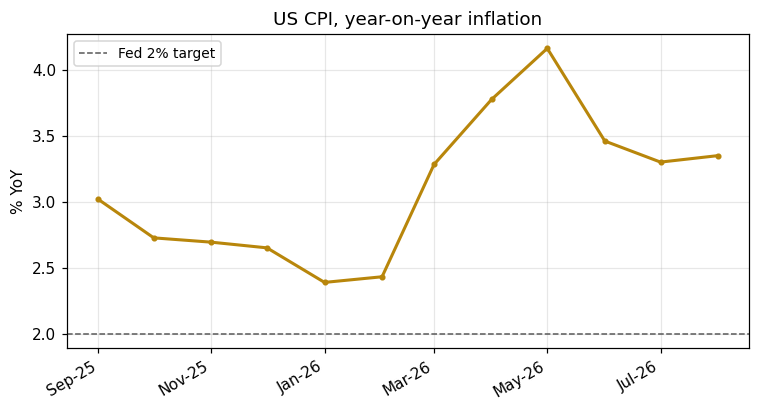

In [1]:
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(cpi.dropna(subset=['yoy'])['date'], cpi.dropna(subset=['yoy'])['yoy'], marker='o')
ax.axhline(2.0, ls='--', label='Fed 2% target')
ax.set_title('US CPI, year-on-year inflation'); ax.legend(); plt.show()

## 3. Latest Treasury curve snapshot

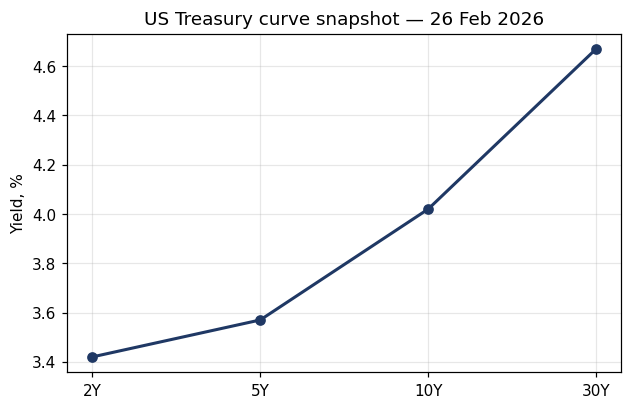

In [1]:
tenors, labels = ['y2','y5','y10','y30'], ['2Y','5Y','10Y','30Y']
latest = ust.iloc[-1]
fig, ax = plt.subplots(figsize=(6.5,4))
ax.plot(labels, [latest[t] for t in tenors], marker='o')
ax.set_title(f"US Treasury curve — {latest['date'].date()}"); plt.show()

## 4. Reading

- Fed funds last printed **3.63%** (Aug 2026), down from 5.33% as recently as mid-2024 — a genuine, multi-cut easing cycle.
- US CPI YoY was **3.4%** as of Aug 2026, still above the Fed's 2% target.
- On the latest available Treasury curve snapshot (26 Feb 2026), the 10Y sat at **4.02%**, +0.60pp above the 2Y — a positively sloped curve.

*(Note: the September 2025 BLS CPI print for October 2025 shows as a data gap in the underlying FRED series — this is a real publication gap, not an error in this notebook, and is left blank rather than interpolated.)*



### Data sources

| Series | Source | Access route |
|---|---|---|
| US CPI (CPIAUCSL) | Federal Reserve Bank of St. Louis, FRED | `fred.stlouisfed.org/data/CPIAUCSL` (public table) |
| US Federal Funds Effective Rate (FEDFUNDS) | Federal Reserve Board via FRED | `fred.stlouisfed.org/data/FEDFUNDS` |
| US Daily Treasury Par Yield Curve (2Y/5Y/10Y/30Y) | U.S. Department of the Treasury | Treasury's public XML feed, `home.treasury.gov/.../pages/xml?data=daily_treasury_yield_curve` |
| UK 10Y gilt yield (IRLTLT01GBM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IRLTLT01GBM156N` |
| UK CPI, all items (GBRCPIALLMINMEI) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/GBRCPIALLMINMEI` |
| UK 3-month interbank rate (IR3TIB01GBM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IR3TIB01GBM156N` |
| Euro area 3-month interbank rate (IR3TIB01EZM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IR3TIB01EZM156N` |
| USD/EUR, USD/GBP, USD/JPY spot | European Central Bank reference rates | Frankfurter API, `api.frankfurter.dev` |

No API keys were used. All series above are genuinely published data pulled on **14 September 2026**; none of the figures in this notebook are simulated or invented.
